## Creating a Linear Regression Model

### Discovery

You have been tasked with trying to determine if there is a linear relationship between the cost of oil and the S&P 500 valuation. You will use a linear regression model to establish if any relationship exists and if so, how oil prices are impacted by stock market fluctuations.

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split

In [1]:
# Import required modules/libraries
import matplotlib.pyplot as plt # Another viz library
import pandas as pd # Used for manipulating data
import seaborn as sns # Visualisations
import statsmodels.api as sm # One of the ML libraries
from sklearn.model_selection import train_test_split # Another ML library
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

--- 
### Data preparation
We import the dataset, telling pandas to set the index column as the date, ensuring it is a datetime format and cofnirming the input format. We then validate the results. 

In [2]:
# Import the first dataset and set the date as the index
stock_df = pd.read_csv("all_stocks_5yr.csv", index_col="Date", parse_dates=True, date_format="%d/%m/%Y")
stock_df.tail(10)

,Open,Close,Low,High
Date,,,,
2017-05-01,97.372383,97.419830,96.640558,98.098995
2017-06-01,99.257088,99.211692,98.359108,100.035781
2017-07-01,99.727727,99.737220,98.919514,100.504129
2017-08-01,98.916925,98.886966,98.150247,99.661740
2017-09-01,100.098283,100.133291,99.288041,100.864258
2017-10-01,102.854219,102.908070,102.036919,103.656867
2017-11-01,103.862055,104.014336,103.020190,104.836911
2017-12-01,106.639923,106.488189,105.682850,107.456124
2018-01-01,111.661892,111.778353,110.634552,112.707958


Next we remove the columns we don't need, and rename the Close column to make it easier to interpret. 

In [3]:
# Removed unrequired data and renamed close price
stock_df = stock_df[["Close"]]
stock_df = stock_df.rename(columns={'Close': 'S&P Close Price $'})
stock_df.tail(10)

,S&P Close Price $
Date,
2017-05-01,97.419830
2017-06-01,99.211692
2017-07-01,99.737220
2017-08-01,98.886966
2017-09-01,100.133291
2017-10-01,102.908070
2017-11-01,104.014336
2017-12-01,106.488189
2018-01-01,111.778353


We then import the oil dataset, replicated the date as index steps from our first dataset. We rename the price columnn and validate. 

In [4]:
# Import the second dataset and set the date as the index
oil_df = pd.read_csv("crude-oil-price.csv", index_col="date", parse_dates=True, date_format="%d/%m/%Y")
oil_df = oil_df[["price"]]
oil_df = oil_df.rename(columns={'price': 'Oil Cost $ (Barrell)'})
oil_df.tail()

,Oil Cost $ (Barrell)
date,
2025-05-01,60.7900
2025-06-01,65.1100
2025-07-01,69.2600
2025-08-01,64.0100
2025-09-01,63.7496


With both datasets imported, we can join the datasets together, using an inner join to remove any rows where dates do not exist in both datasets. 

In [5]:
# Combine both dataframes together using an inner join. 
join_df = oil_df.join(stock_df , how="inner")
join_df.head()

,Oil Cost $ (Barrell),S&P Close Price $
2013-02-01,92.05,58.106483
2013-03-01,97.23,59.531515
2013-04-01,93.46,60.294833
2013-05-01,91.97,63.284582
2013-06-01,96.56,61.994978


Our final step is to check the number of rows matches, for both columns, and to check the datatypes are numeric. 

In [6]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2013-02-01 to 2018-02-01
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Oil Cost $ (Barrell)  61 non-null     float64
 1   S&P Close Price $     61 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


--- 
### Model planning
You will now need to understand which variables have a relationship from the prepared data. Identifying the strength and direction of the relationships will help to build a useful model, within the remit of the task. 

We first create a correlation matrix to establish the relationships between variables. We will only use 1 indepednent and 1 depedant variable for this model. 

<Axes: >

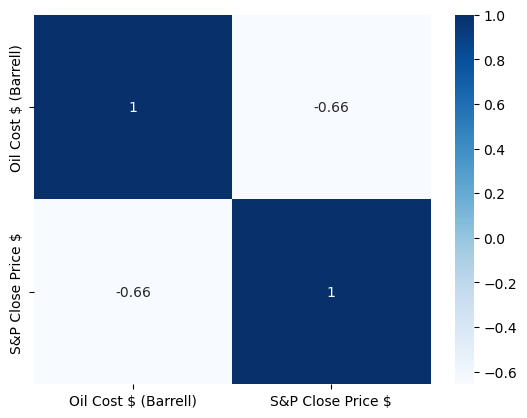

In [7]:
# Use price as dependent and select another appropriate variable to predict the output. 
join_corr = join_df.corr()
sns.heatmap(join_corr, annot=True, cmap="Blues")

Create a Regplot/Scatterplot to demonstrate the relationship between our dependent and independent variable. 

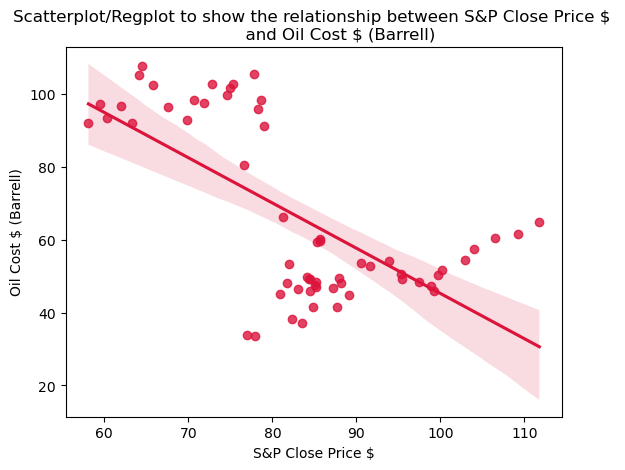

In [8]:
# Check the relationship between the selected variables
sns.regplot(x = "S&P Close Price $",
            y = "Oil Cost $ (Barrell)",
            color="Crimson",
            data = join_df)

# Add title with multiline string and new line
plt.title("""Scatterplot/Regplot to show the relationship between S&P Close Price $ 
          and Oil Cost $ (Barrell)""")

# Display visual with title
plt.show()

---
### Building the model
Before building the model we split the data into training and test datasets. The model will be build using the train data and tested using the test data. We include the random_state argument to make the results replicable: <br>

In [9]:
# Split the data into train and test samples
train, test = train_test_split(join_df,random_state=25)

We then set the independent variable and dependent variables. <br>
Y/Dependent/Output - the variable we are predicting <br>
X/Independent/Input Variable(s) - the variable(s) we are testing the impact of.

In [10]:
# Set the dependent variable and validate
dep = train["Oil Cost $ (Barrell)"]
dep.head()

2015-05-01     60.30
2017-10-01     54.38
2013-08-01    107.65
2016-02-01     33.75
2014-01-01     97.49
Name: Oil Cost $ (Barrell), dtype: float64

Add the constant to the independent variable where we do not wish the intercept/c to run through zero. This makes sense in this example as Oil would still hold value in other currencies, should the S&P 500 crash. 

In [11]:
# Set the independent variable and validate
ind = train["S&P Close Price $"]
ind = sm.add_constant(ind)
ind.head()

,const,S&P Close Price $
2015-05-01,1.0,85.705089
2017-10-01,1.0,102.908070
2013-08-01,1.0,64.504099
2016-02-01,1.0,76.983138
2014-01-01,1.0,71.825667


Now generate the model along with a summary output. 

In [12]:
# Fit the model and produce the summary
model = sm.OLS(dep,ind).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Oil Cost $ (Barrell)   R-squared:                       0.498
Model:                              OLS   Adj. R-squared:                  0.487
Method:                   Least Squares   F-statistic:                     42.71
Date:                  Wed, 27 May 2026   Prob (F-statistic):           6.08e-08
Time:                          15:22:42   Log-Likelihood:                -189.39
No. Observations:                    45   AIC:                             382.8
Df Residuals:                        43   BIC:                             386.4
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               175.7521     16.942     10.374      0.000     141.585     209.919
S&P Close Price $    -1.3205      0.202     -6.535      0.000      -1.728      -0.913
==============================================================================
Omnibus:                        0.024   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.988   Jarque-Bera (JB):                0.203
Skew:                          -0.010   Prob(JB):                        0.903
Kurtosis:                       2.671   Cond. No.                         572.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

--- 
### Communicating the results. 
We will now analyse the model and communicate the results, paying particular focus on the following ouptuts.

- R-Squared (R²) : R-squared measures the proportion of the variance in the dependent variable that is explained by the independent variables. It ranges from 0 to 1, where 1 indicates that the model explains all the variance.

- F-Statistic: The F-statistic is used to test the overall significance of the model. The null hypothesis is that all coefficients (except the intercept) are zero, meaning the model does not explain any variance in the dependent variable. This value should be greater than 1 but the higher the number, the better.  

- Prob (F-Statistic): - The p-value associated with the F-statistic indicates the probability of observing the F-statistic (or a more extreme value) if the null hypothesis were true. A small p-value (typically less than 0.05) indicates that the model is statistically significant, meaning at least one of the independent variables has a significant effect on the dependent variable.


- P-Value: The p-value indicates the probability of observing the estimated coefficient if the null hypothesis were true. A p-value below a certain significance level (usually 0.05) suggests that the coefficient is statistically significant, meaning the independent variable has a significant effect on the dependent variable.

- Coefficient: The coefficient term tells the change in Y for a unit change in X. In our model a 1 unit change in S&P Close Price will lead to a 1.3205 decrease in Oil Cost.

- Constant: The constant terms is the intercept of the regression line. This represents the baseline of a the output variable, assuming input variables are set to 0.

Now lets test the model output - remember to add a constant to your test data. 

In [13]:
# Set the test sample independent variable and use the model to predict the variable, using the test dataset 
test_ind = test[["S&P Close Price $"]]
test_ind = sm.add_constant(test_ind)
output = model.predict(test_ind)

In [25]:
print(test["Oil Cost $ (Barrell)"].max())

102.59


Finally, add a predicted column to your test dataset, where you have your prediction shown, alongside your actual values for your dependent variable. 

In [14]:
# Add the predicted values to our test dataframe to compare actual with predicted. 
test["predicted"] = output
test.head()
#test = pd.to_csv("outputdata")

,Oil Cost $ (Barrell),S&P Close Price $,predicted
2014-02-01,102.59,72.859147,79.543491
2014-03-01,101.58,74.899410,76.849376
2014-04-01,99.74,74.578316,77.273373
2014-09-01,91.16,79.037900,71.384607
2013-09-01,102.33,65.744264,88.938510


With the predicted values, to compare against what actual values, we can calculate some additional statistics to validate the quality of our model.
- RMSE - the square root of the average of squared prediction errors, which shows how far predictions are from actual values with bigger mistakes weighted more heavily.
- MAPE - the average percentage difference between predicted and actual values, which shows prediction error in percent terms.
- MAE - the average of the absolute prediction errors, which shows the typical size of mistakes without caring whether they are above or below the actual values.
- MSE - the average of squared prediction errors, which shows overall error while giving extra weight to larger mistakes.

In [15]:
# Root mean squared error - 
rmse = root_mean_squared_error(test["Oil Cost $ (Barrell)"],test["predicted"])
print(rmse)

21.95468460554666


In [16]:
mape = mean_absolute_percentage_error(test["Oil Cost $ (Barrell)"],test["predicted"])
print(mape)

0.36809743162776215


In [17]:
mae = mean_absolute_error(test["Oil Cost $ (Barrell)"],test["predicted"])
print(mae)

20.178242540025543


In [18]:
mse = mean_squared_error(test["Oil Cost $ (Barrell)"],test["predicted"])
print(mse)

482.00817612902745


We can go further than this if we wanted to, and measure the actual values against the predicted to see how well they align. Additionally, we might like to plot residuals to see the dispersion of outliers. Outliers close to zero are preferred, with a normal distribution. 

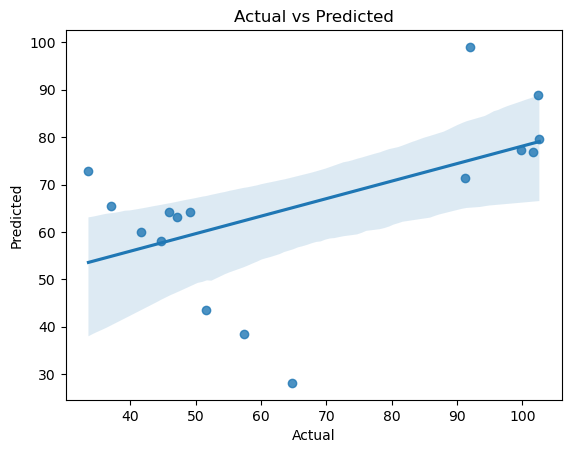

In [19]:
# Plot the actual, compared with predicted. 
# Should be on a 45° incline to show good predictions.
sns.regplot(x="Oil Cost $ (Barrell)", y="predicted", data = test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

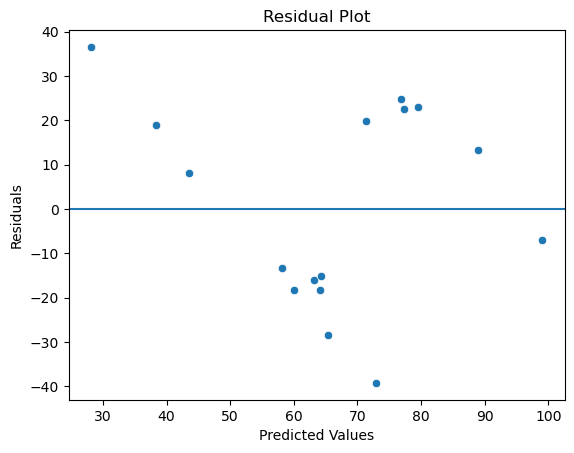

In [20]:
# Plot redsiduals to understand dispersion of outliers.
# Should be centered around 0

residuals = test["Oil Cost $ (Barrell)"] - test["predicted"]
sns.scatterplot(x=test["predicted"], y=residuals, data = test)

plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



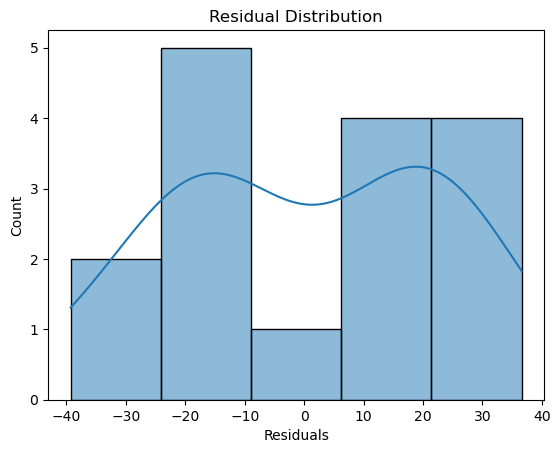

In [21]:
# Plot the distribution of residuals 
# Should look like a bell-curve when correct
sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Residual Distribution")

plt.show()

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. In this case, I am simply going to create a small sample dataset, and run this through the model to compare what the model predicted would happen, against what actually did. 

In [22]:
# Created a dictionary of new data.
new_data = {
    "Oil Cost $ (Barrell)": [100, 200, 72.50, 60, 45.30], # dependent variable
    "S&P Close Price $": [60.50, 65.45, 62.20, 60.50, 65.45] # ndependent variable
}

# Convert the dictionary to a dataframe. 
new_data_df = pd.DataFrame(new_data)
new_data_df.head()


,Oil Cost $ (Barrell),S&P Close Price $
0,100.0,60.50
1,200.0,65.45
2,72.5,62.20
3,60.0,60.50
4,45.3,65.45


In [23]:
# Create the new independent variable and add constant. 
new_ind = new_data_df["S&P Close Price $"]
new_ind = sm.add_constant(new_ind)
new_ind.head()

,const,S&P Close Price $
0,1.0,60.50
1,1.0,65.45
2,1.0,62.20
3,1.0,60.50
4,1.0,65.45


In [24]:
# Run the new data through the model and generate predictions
output = model.predict(new_ind)
new_data_df["predicted"] = output
new_data_df.head()

,Oil Cost $ (Barrell),S&P Close Price $,predicted
0,100.0,60.50,95.863425
1,200.0,65.45,89.327078
2,72.5,62.20,93.618619
3,60.0,60.50,95.863425
4,45.3,65.45,89.327078
